In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/syedaeman2212/top-100-universities/top_100_universities_dataset.csv


## LOAD DATA 

In [32]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import shap
import joblib


In [33]:


df = pd.read_csv("/kaggle/input/datasets/syedaeman2212/top-100-universities/top_100_universities_dataset.csv")
df.columns = df.columns.str.strip()
df = df.drop_duplicates()


In [34]:
# Convert numeric columns
num_cols = ["Position","Established_Year","Total_Students","Number_of_Campuses",
            "Programs_Offered","Total_Faculty","Campus_Area_Acres"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

## BIN RANKINGS INTO 2 CLASSES


In [35]:

# 0 = Top 25, 1 = Rest
df["Rank_Class"] = df["Position"].apply(lambda x: 0 if x <= 25 else 1)

## FEATURE ENGINEERING

In [36]:

CURRENT_YEAR = 2026
df["University_Age"] = CURRENT_YEAR - df["Established_Year"]
df["Student_Faculty_Ratio"] = df["Total_Students"] / df["Total_Faculty"]
df["Programs_Per_Campus"] = df["Programs_Offered"] / df["Number_of_Campuses"]
df["Students_Per_Campus"] = df["Total_Students"] / df["Number_of_Campuses"]
df["Campus_Density"] = df["Total_Students"] / df["Campus_Area_Acres"]
df["Country"] = df["Location"].apply(lambda x: x.split(",")[-1].strip())


## LOG TRANSFORM SKEWED FEATURES


In [37]:

for col in ["Total_Students","Total_Faculty","Campus_Area_Acres"]:
    df[col] = np.log1p(df[col])

## ENCODING

In [38]:

cat_cols = ["University_Type","Country"]
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

## FEATURES & TARGET

In [39]:

features = ["Established_Year","Total_Students","Number_of_Campuses","Programs_Offered",
            "Total_Faculty","Campus_Area_Acres","University_Type","Country",
            "University_Age","Student_Faculty_Ratio","Programs_Per_Campus",
            "Students_Per_Campus","Campus_Density"]

target = "Rank_Class"

X = df[features]
y = df[target]


## TRAIN TEST SPLIT

In [40]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## HANDLE IMBALANCE WITH SMOTE


In [41]:

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


## SCALING

In [42]:

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)


## RANDOM FOREST CLASSIFIER

In [43]:

rf_clf = RandomForestClassifier(n_estimators=500, max_depth=12, random_state=42)
rf_clf.fit(X_train_res, y_train_res)

y_pred = rf_clf.predict(X_test)

##  EVALUATION

Accuracy: 0.6500

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.20      0.22         5
           1       0.75      0.80      0.77        15

    accuracy                           0.65        20
   macro avg       0.50      0.50      0.50        20
weighted avg       0.62      0.65      0.64        20



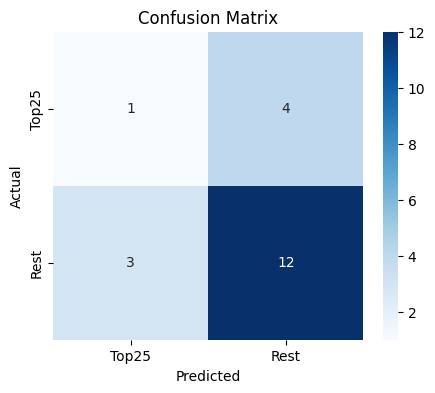

In [44]:

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Top25","Rest"],
            yticklabels=["Top25","Rest"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## CROSS-VALIDATION

In [45]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_clf, scaler.transform(X), y, cv=cv, scoring="accuracy")
print(f"5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f}")

5-Fold Cross-Validation Accuracy: 0.7100


## FEATURE IMPORTANCE (SHAP)

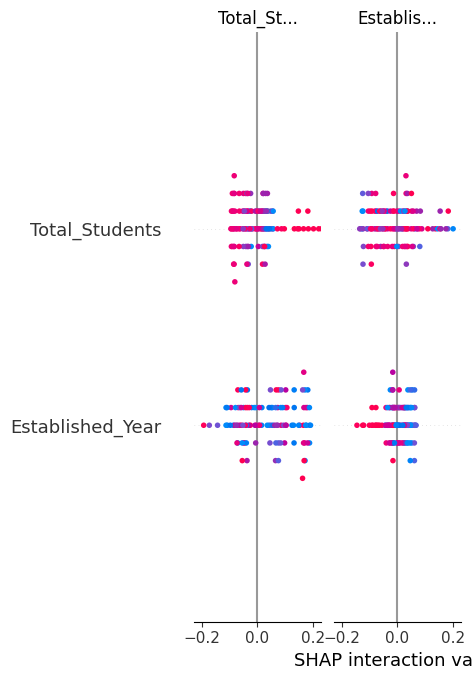

In [46]:

explainer = shap.Explainer(rf_clf)
shap_values = explainer(X_train_res)
shap.summary_plot(shap_values, X_train_res, feature_names=features, plot_type="bar")


##  VISUALIZATIONS

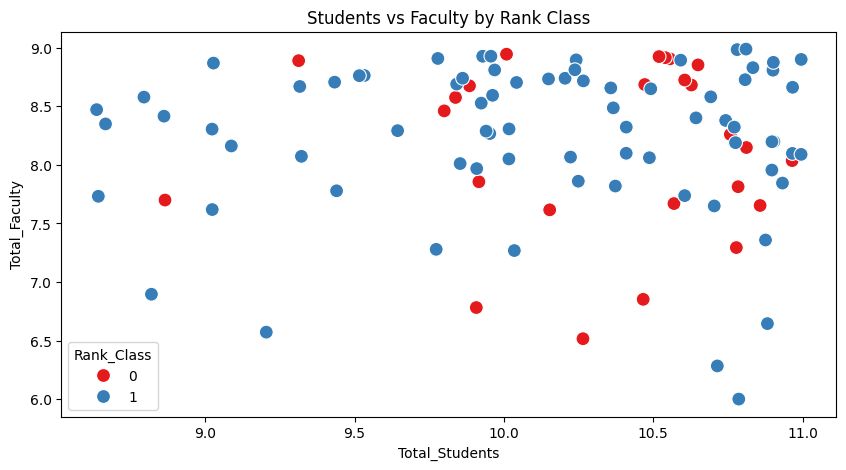

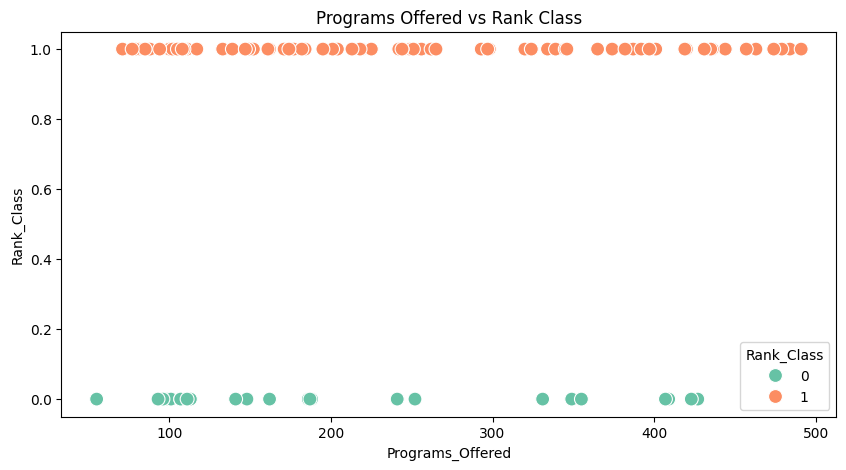

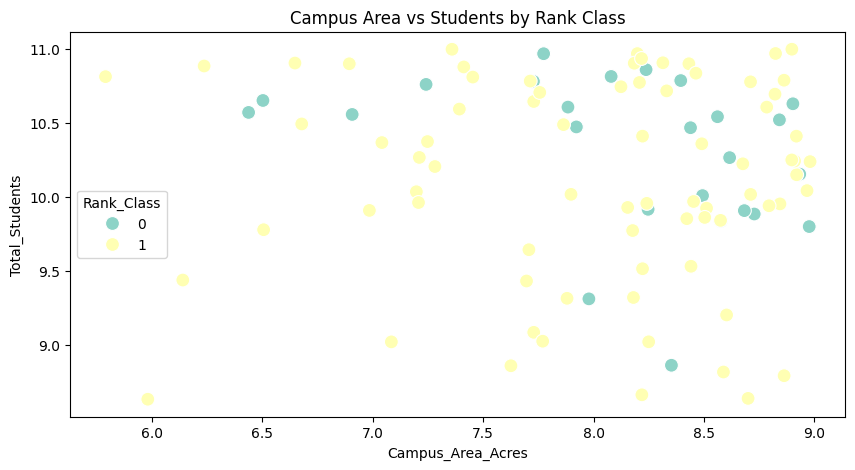

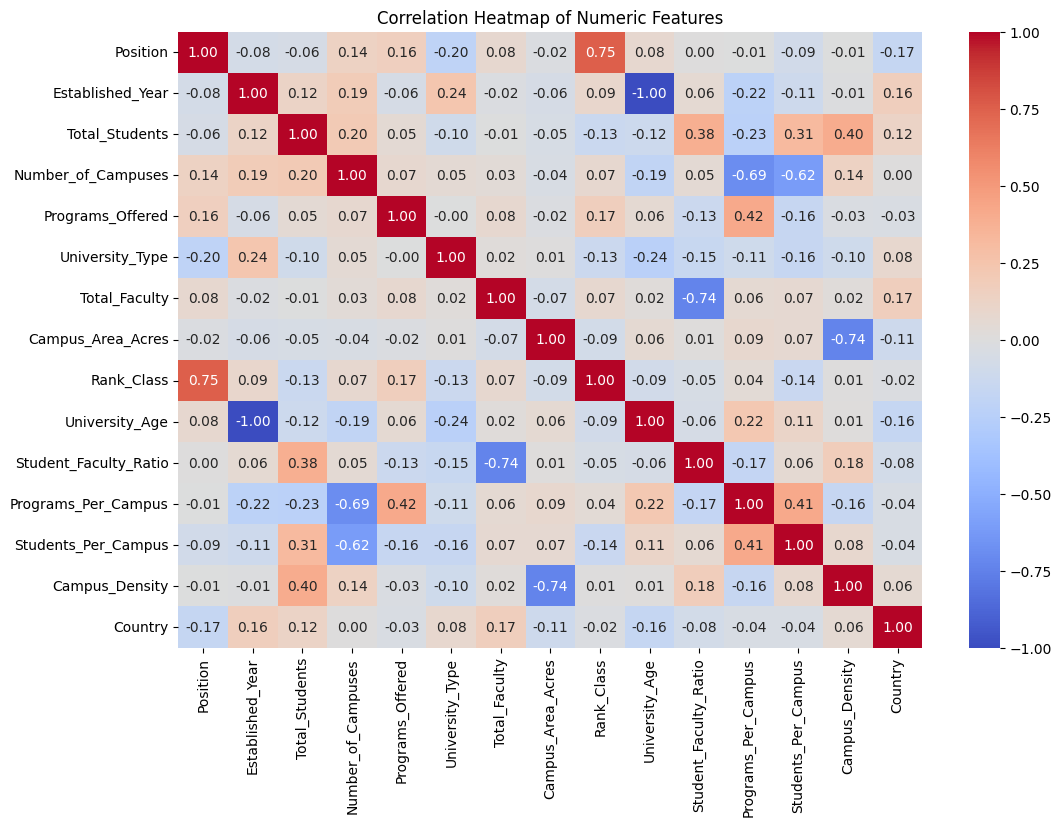

In [47]:

plt.figure(figsize=(10,5))
sns.scatterplot(x="Total_Students", y="Total_Faculty", hue="Rank_Class", palette="Set1", s=100, data=df)
plt.title("Students vs Faculty by Rank Class")
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(x="Programs_Offered", y="Rank_Class", hue="Rank_Class", palette="Set2", s=100, data=df)
plt.title("Programs Offered vs Rank Class")
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(x="Campus_Area_Acres", y="Total_Students", hue="Rank_Class", palette="Set3", s=100, data=df)
plt.title("Campus Area vs Students by Rank Class")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()



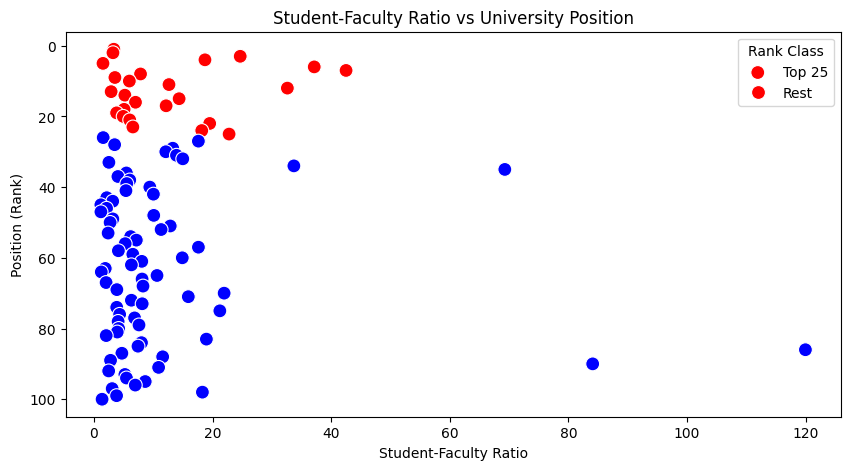

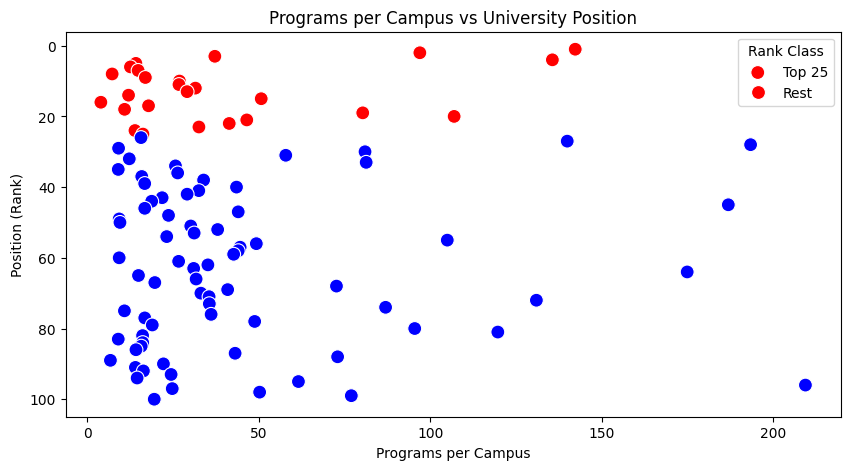

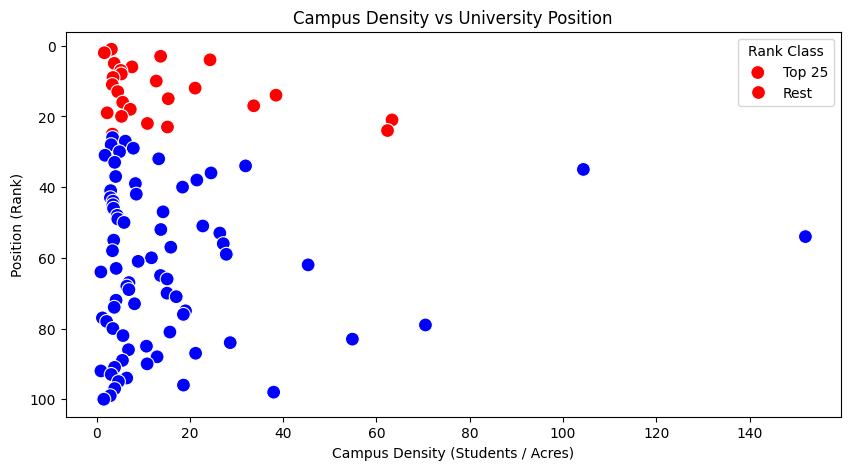

In [48]:

# SCATTERPLOTS: FEATURES VS RANK CLASS

plt.figure(figsize=(10,5))
sns.scatterplot(x="Student_Faculty_Ratio", y="Position", hue="Rank_Class",
                palette={0:"red", 1:"blue"}, s=100, data=df)
plt.title("Student-Faculty Ratio vs University Position")
plt.xlabel("Student-Faculty Ratio")
plt.ylabel("Position (Rank)")
plt.gca().invert_yaxis()  # Higher rank = lower position
plt.legend(title="Rank Class", labels=["Top 25", "Rest"])
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(x="Programs_Per_Campus", y="Position", hue="Rank_Class",
                palette={0:"red", 1:"blue"}, s=100, data=df)
plt.title("Programs per Campus vs University Position")
plt.xlabel("Programs per Campus")
plt.ylabel("Position (Rank)")
plt.gca().invert_yaxis()
plt.legend(title="Rank Class", labels=["Top 25", "Rest"])
plt.show()

plt.figure(figsize=(10,5))
sns.scatterplot(x="Campus_Density", y="Position", hue="Rank_Class",
                palette={0:"red", 1:"blue"}, s=100, data=df)
plt.title("Campus Density vs University Position")
plt.xlabel("Campus Density (Students / Acres)")
plt.ylabel("Position (Rank)")
plt.gca().invert_yaxis()
plt.legend(title="Rank Class", labels=["Top 25", "Rest"])
plt.show()



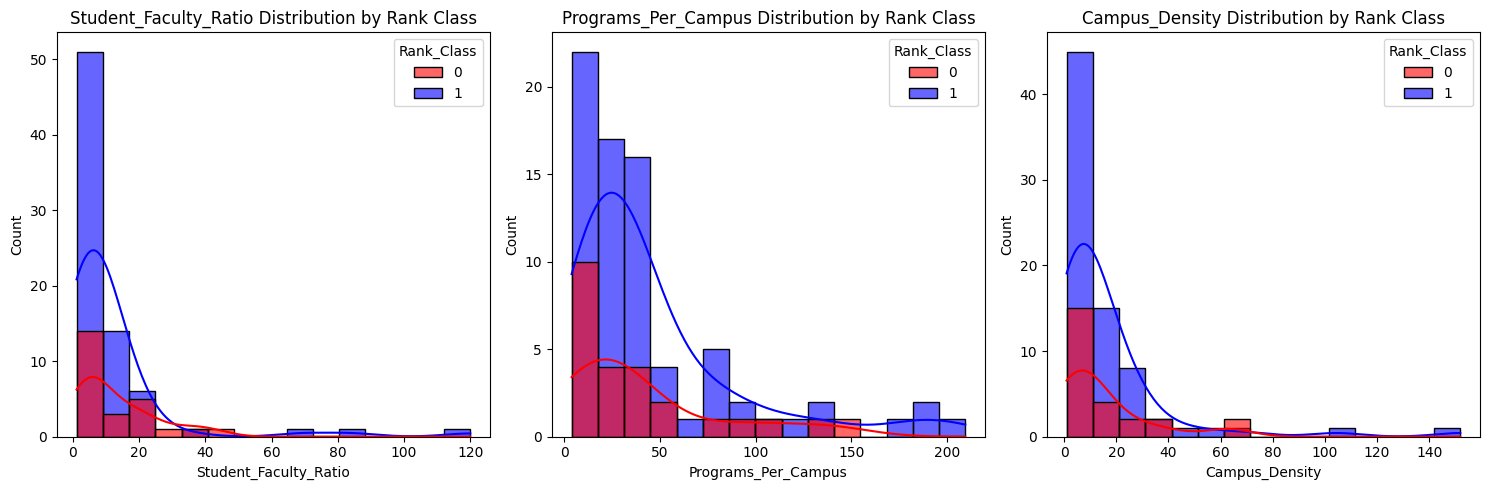

In [49]:

# HISTOGRAMS: FEATURE DISTRIBUTIONS BY CLASS

features_to_plot = ["Student_Faculty_Ratio", "Programs_Per_Campus", "Campus_Density"]
plt.figure(figsize=(15,5))

for i, feat in enumerate(features_to_plot, 1):
    plt.subplot(1,3,i)
    sns.histplot(data=df, x=feat, hue="Rank_Class", palette={0:"red",1:"blue"},
                 bins=15, kde=True, alpha=0.6)
    plt.title(f"{feat} Distribution by Rank Class")
plt.tight_layout()
plt.show()

In [50]:

joblib.dump(rf_clf, "university_rank_2class_model.pkl")
print("2-Class Rank Classification Model Saved Successfully!")

2-Class Rank Classification Model Saved Successfully!
